# ACSC (Aspect Category Sentiment Classification)  
- No (ATE) aspect term extraction step. Instead, it feeds the Ground Truth Aspects from the gold set directly into the models to test its ability to express sentiment.
- Author: Joel Hultman joehu131

### [1] – Imports, metrics, and device setup

Initializes the experiment environment.

- Loads utilities for JSONL parsing and result handling (`json`, `pandas`).
- Imports PyTorch and Transformers for running DeBERTa inference.
- Imports scikit-learn metrics for later evaluation (F1, confusion matrix, classification report).
- Selects GPU if CUDA is available, otherwise CPU, and prints the chosen device.


In [1]:
import json
import torch
import spacy
import pandas as pd
import time
from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Setup Device (GPU vs CPU)
# This checks if Cuda is available to use onboard GPU (RTX 3070)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # torch device object
device_str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_str}")

Using device: cuda


### [2] – File paths and model configuration

Defines all experiment configuration

- Declares paths for raw reviews, gold annotations, and the fixed aspect list.
- Sets the DeBERTa ABSA model checkpoint used for sentiment classification.
- Keeps commented parameters for aspect extraction, which are not used here since this is an ASC setup.


In [2]:
# Paths
RAW_DATA_PATH = '../data/raw_reviews_cleanser.jsonl'  
SENTENCE_DATA_PATH = '../data/cleanser_sentences.jsonl'
GOLD_DATA_PATH = '../data/gold_set_cleanser_version_2.jsonl'  
ASPECTS_LIST_PATH = '../data/aspectsv2.jsonl'  

# Model Configuration

# Threshold for Aspect Term Extraction (ATE)
# If the MNLI model predicts a probability higher than this, we assume the aspect is present.
# You can tune this: 0.4 finds more (Higher Recall), 0.7 finds fewer (Higher Precision).
#ATE_THRESHOLD = 0.7 

# Model names from Hugging Face
#ATE_MODEL_NAME = "facebook/bart-large-mnli"  # Zero-shot classifier for detecting aspects

#DEBERTA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"
DEBERTA_MODEL = "yangheng/deberta-v3-large-absa-v1.1"

### [3] – Sentence splitting using spaCy
- This block is only needed if you are generating `cleanser_sentences.jsonl` from full reviews.
- If `SENTENCE_DATA_PATH` already exists and is correct, you can skip running this entire block.


In [3]:
nlp = spacy.load("en_core_web_sm")

nlp.disable_pipes(*[p for p in nlp.pipe_names if p != "sentencizer"])
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer")

def split_reviews_to_sentences(input_file, output_file):
    print(f"Processing {input_file}")

    with open(input_file, "r", encoding="utf-8") as f_in, \
         open(output_file, "w", encoding="utf-8") as f_out:

        for line in tqdm(f_in):
            try:
                data = json.loads(line)
                review_id = data["review_id"]
                text = data["review_text"]

                text = text.strip('"')
                
                doc = nlp(text)

                sent_idx = 0
                for sent in doc.sents:
                    sent_text = sent.text.strip()
                    if not sent_text:
                        continue
                    sent_idx += 1

                    output_entry = {
                        "review_id": f"{review_id}_{sent_idx}",
                        "review_sentence": sent_text
                    }
                    f_out.write(json.dumps(output_entry, ensure_ascii=False) + "\n")

            except json.JSONDecodeError:
                print(f"Skipping invalid JSON line: {line[:80]}...")
                continue

    print(f"Done. Sentences saved to {output_file}")


# Execute the function
# split_reviews_to_sentences(RAW_DATA_PATH, SENTENCE_DATA_PATH)

### [4] – Load raw reviews and gold aspect pairs

Loads the datasets used for evaluation.

- Reads raw sentences into a dictionary keyed by `review_id` for fast lookup.
- Loads the gold JSONL annotations into memory.
- Prints dataset sizes for basic sanity checking.


In [4]:
# 1. Load Raw Reviews Sentences
raw_sentences = {}
with open(SENTENCE_DATA_PATH, 'r', encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        raw_sentences[data['review_id']] = data['review_sentence']
print(f"Loaded {len(raw_sentences)} raw sentences for context.")

# 2. Load Gold Annotations
gold_data = []
with open(GOLD_DATA_PATH, 'r', encoding="utf-8") as f:
    for line in f:
        gold_data.append(json.loads(line))

print(f"Loaded {len(gold_data)} gold aspect pairs to classify.")

# Sentence data format: {"review_id": "C5_1_1", "review_sentence": "attention oily skinned people: this face wash is great."}
# Gold data format {"review_id":"C5_1_1","text_pair":"overall satisfaction","label":"Positive"," review_sentence ":"attention oily skinned people: this face wash is great."}

Loaded 198 raw sentences for context.
Loaded 162 gold aspect pairs to classify.


### [5] – Load DeBERTa model and tokenizer

Initializes the sentiment model.

- Loads tokenizer and sequence classification model from Hugging Face.

In [5]:
print(f"Loading model: {DEBERTA_MODEL}...")

tokenizer = AutoTokenizer.from_pretrained(DEBERTA_MODEL, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_MODEL).to(device) # Move model to device
model.eval() # Freeze model for inference

# Get label mapping (0: Negative, 1: Neutral, 2: Positive)
id2label = model.config.id2label
label2id = model.config.label2id

print("Model loaded successfully!")

print("Label mapping (id -> label):")
for k, v in id2label.items():
    print(f"  {k} -> {v}")

print("\nLabel mapping (label -> id):")
for k, v in label2id.items():
    print(f"  {k} -> {v}")

Loading model: yangheng/deberta-v3-large-absa-v1.1...
Model loaded successfully!
Label mapping (id -> label):
  0 -> Negative
  1 -> Neutral
  2 -> Positive

Label mapping (label -> id):
  Negative -> 0
  Neutral -> 1
  Positive -> 2


### [6] – DeBERTA ACSC inference loop

Runs the core sentiment classification experiment.

- Uses gold aspects directly (Oracle setup) instead of predicting aspects.
- Runs inference in batches for higher GPU throughput.
- Feeds the model paired inputs: full sentence text and aspect category.
- Converts "logits" to probabilities and selects the highest-scoring label.
- Stores predictions and example logs for later analysis.

In [6]:
predictions = []
true_labels = []
results_list = []

BATCH_SIZE = 16

print("Running Oracle ACSC Inference")

def base_sentence_id(review_id: str) -> str:
    #Gold IDs may look like 'C5_1_2:1' to store multiple aspects for one sentence.
    #Sentence data uses the base id without the ':k' suffix (e.g., 'C5_1_2').
    return review_id.split(":", 1)[0]

# ---- Timing start ----
start_time = time.time()
total_inferences = 0

# Process in batches for speed
for i in tqdm(range(0, len(gold_data), BATCH_SIZE)):
    batch = gold_data[i : i + BATCH_SIZE]

    # Prepare batch inputs
    texts = []
    aspects = []
    used_ids = []  # Track which sentence-id we actually looked up

    for item in batch:
        # Normalize gold id -> sentence id
        sent_id = base_sentence_id(item["review_id"])
        sentence_text = raw_sentences[sent_id]

        texts.append(sentence_text)
        aspects.append(item["text_pair"])  # The Aspect Category (e.g., "product value")
        used_ids.append(sent_id)

    # Tokenize: [CLS] Sentence [SEP] Aspect Category [SEP]
    inputs = tokenizer(
        texts,
        aspects,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(device)

    # Inference
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits -> probabilities
    probs = torch.softmax(outputs.logits, dim=-1)

    # Get Predictions
    pred_ids = torch.argmax(outputs.logits, dim=-1)

    # Store results
    for j, pred_id in enumerate(pred_ids):
        item = batch[j]
        pred_label = id2label[pred_id.item()]
        pred_score = probs[j, pred_id].item()  # confidence of predicted class
        
        predictions.append(pred_label)
        true_labels.append(item["label"])

        # Save detailed log
        text_preview = texts[j]
        results_list.append({
            "review_id": item["review_id"],        # Keep the original gold id (with :k)
            "sentence_id": used_ids[j],            # Also store the base id used for lookup
            "aspect": item["text_pair"],
            "true_label": item["label"],
            "pred_label": pred_label,
            "pred_score": round(pred_score, 4),
            "is_correct": (pred_label == item["label"]),
            "text_used": text_preview
        })
        
        total_inferences += 1

# ---- Timing end (after loop finishes) ----
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / total_inferences

print("Inference complete.")
print(f"Total inferences: {total_inferences}")
print(f"Total runtime: {total_time:.2f} seconds")
print(f"Average time per inference: {avg_time:.4f} seconds")
print(f"Throughput: {total_inferences / total_time:.2f} inferences/sec")

Running Oracle ACSC Inference


100%|██████████| 11/11 [00:01<00:00,  7.29it/s]

Inference complete.
Total inferences: 162
Total runtime: 1.51 seconds
Average time per inference: 0.0093 seconds
Throughput: 107.06 inferences/sec


### [7] – DeBERT Evaluation and export

Evaluates model performance and saves results.

- Computes macro F1 and prints a classification report.
- Builds a results table and extracts incorrect predictions for inspection.
- Exports all predictions to CSV for comparison with other baselines.

In [7]:
# Quantitative Metrics
print("--- ACSC Performance (DeBERTa) ---")
macro_f1 = f1_score(true_labels, predictions, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

# Qualitative Error Analysis
df_oracle = pd.DataFrame(results_list)
errors = df_oracle[df_oracle['is_correct'] == False]

print(f"\nError Analysis: Failed on {len(errors)} out of {len(df_oracle)} examples.")
print("Top 5 Errors (with model confidence):")

display(
    errors[['review_id', 'aspect', 'true_label', 'pred_label', 'pred_score', 'text_used']]
    .sort_values("pred_score", ascending=True)
    .head(15)
)

# 3. Save for Comparison
df_oracle.to_csv("oracle_deberta_results.csv", index=False)
print("\nSaved results to 'oracle_deberta_results.csv'.")


--- ACSC Performance (DeBERTa) ---
Macro F1 Score: 0.6096

Classification Report:

              precision    recall  f1-score   support

    Negative       0.97      0.60      0.74        52
     Neutral       0.19      0.40      0.26        10
    Positive       0.80      0.87      0.83       100

    accuracy                           0.75       162
   macro avg       0.65      0.62      0.61       162
weighted avg       0.82      0.75      0.77       162


Error Analysis: Failed on 40 out of 162 examples.
Top 5 Errors (with model confidence):


,review_id,aspect,true_label,pred_label,pred_score,text_used
157,C1_3_2,moisturizing effect,Negative,Positive,0.3802,makes my face feel so dry!
97,C3_8_5:2,moisturizing effect,Negative,Positive,0.4801,"made my skin feel clean, but tight and dry."
147,C3_33_1,overall satisfaction,Negative,Positive,0.5064,it doesn’t work for oily face
1,C5_1_2:1,cleansing performance,Neutral,Positive,0.5094,i have very oily skin so it is very important ...
125,C3_22_2,overall satisfaction,Negative,Positive,0.5187,will not be buying again.
118,C3_20_2,cleansing performance,Negative,Neutral,0.5271,"however, i don't think i'm getting a big diffe..."
129,C3_24_1:2,skin reaction,Positive,Neutral,0.5827,the cerave foaming facial cleanser is great fo...
48,C5_12_3:1,moisturizing effect,Positive,Neutral,0.5852,"doesn’t dry me out, it lathers up so nice, and..."
154,C1_2_1,overall satisfaction,Negative,Neutral,0.6375,"terrible, made my skin more oily."
132,C3_24_2:3,moisturizing effect,Negative,Positive,0.6587,it lathers well and leaves the skin feeling cl...



Saved results to 'oracle_deberta_results.csv'.


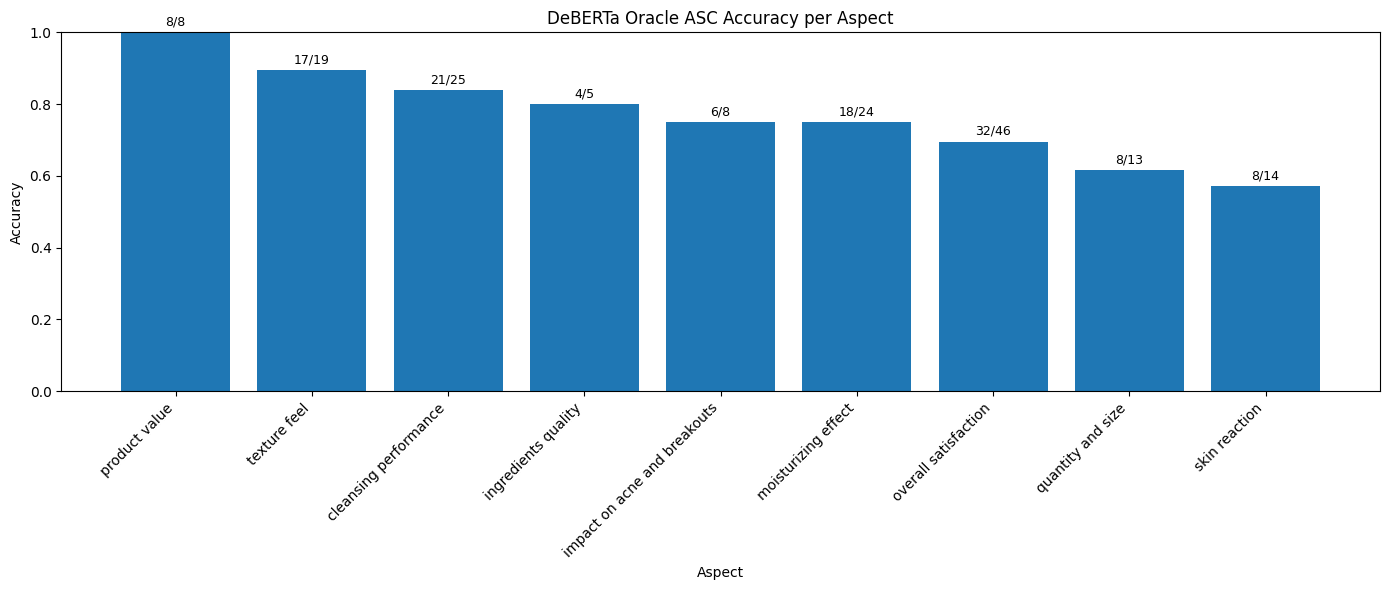

,aspect,total,correct,accuracy
5,product value,8,8,1.000000
8,texture feel,19,17,0.894737
0,cleansing performance,25,21,0.840000
2,ingredients quality,5,4,0.800000
1,impact on acne and breakouts,8,6,0.750000
3,moisturizing effect,24,18,0.750000
4,overall satisfaction,46,32,0.695652
6,quantity and size,13,8,0.615385
7,skin reaction,14,8,0.571429


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Build dataframe from results
df_oracle = pd.DataFrame(results_list)

# Compute accuracy per aspect
aspect_perf = df_oracle.groupby("aspect").agg(
    total=("aspect", "size"),
    correct=("is_correct", "sum")
).reset_index()

aspect_perf["accuracy"] = aspect_perf["correct"] / aspect_perf["total"]

# Sort from best to worst
aspect_perf = aspect_perf.sort_values("accuracy", ascending=False)

# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(aspect_perf["aspect"], aspect_perf["accuracy"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Aspect")
plt.title("DeBERTa Oracle ASC Accuracy per Aspect")
plt.ylim(0, 1)

# Add labels on bars
for bar, total, correct in zip(bars, aspect_perf["total"], aspect_perf["correct"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{correct}/{total}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

display(aspect_perf)


C:\Users\joels\AppData\Local\Temp\ipykernel_28512\979752454.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_perf = df_oracle.groupby("length_bin").agg(


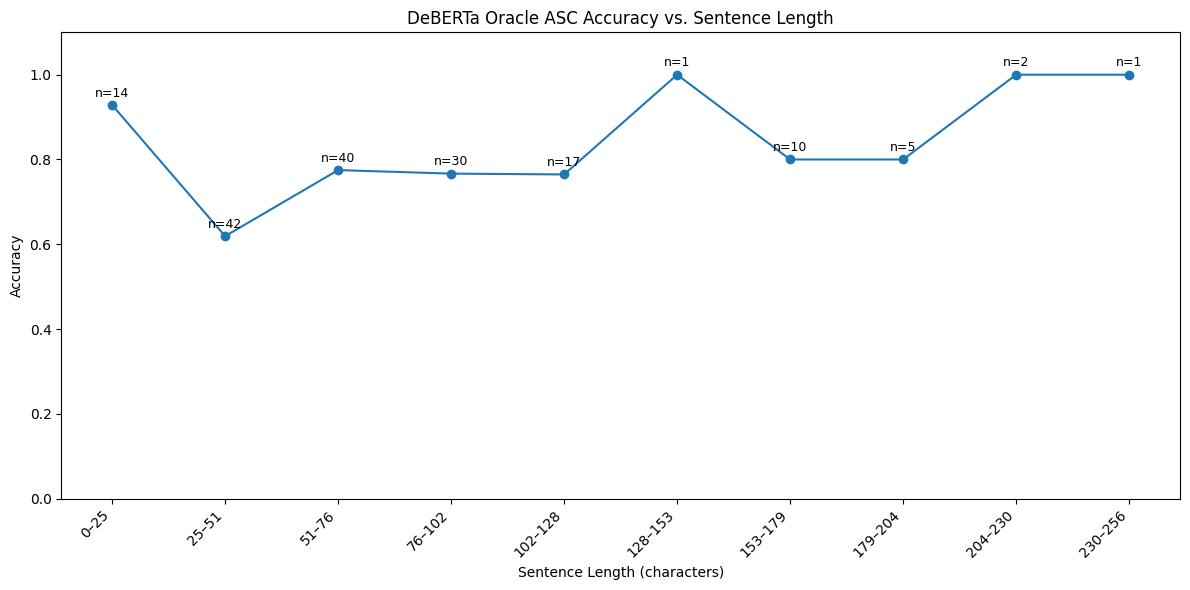

,length_bin,total,correct,accuracy,bin_label
0,"(-0.001, 25.0]",14,13,0.928571,0–25
1,"(25.0, 51.0]",42,26,0.619048,25–51
2,"(51.0, 76.0]",40,31,0.775000,51–76
3,"(76.0, 102.0]",30,23,0.766667,76–102
4,"(102.0, 128.0]",17,13,0.764706,102–128
5,"(128.0, 153.0]",1,1,1.000000,128–153
6,"(153.0, 179.0]",10,8,0.800000,153–179
7,"(179.0, 204.0]",5,4,0.800000,179–204
8,"(204.0, 230.0]",2,2,1.000000,204–230
9,"(230.0, 256.0]",1,1,1.000000,230–256


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Build dataframe from existing results
df_oracle = pd.DataFrame(results_list)

# Add text length feature
df_oracle["text_length"] = df_oracle["text_used"].apply(len)
df_oracle["correct"] = df_oracle["is_correct"].astype(int)

# Define integer bins
max_len = df_oracle["text_length"].max()
bin_edges = np.linspace(0, max_len, 11).astype(int)

# Create bins
df_oracle["length_bin"] = pd.cut(
    df_oracle["text_length"],
    bins=bin_edges,
    include_lowest=True
)

# Computer accuracy per length bin
length_perf = df_oracle.groupby("length_bin").agg(
    total=("correct", "size"),
    correct=("correct", "sum")
).reset_index()

length_perf["accuracy"] = length_perf["correct"] / length_perf["total"]

# Build clean string labels without decimals
length_perf["bin_label"] = length_perf["length_bin"].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(length_perf)), length_perf["accuracy"], marker="o")

plt.xticks(
    range(len(length_perf)),
    length_perf["bin_label"],
    rotation=45,
    ha="right"
)

plt.xlabel("Sentence Length (characters)")
plt.ylabel("Accuracy")
plt.title("DeBERTa Oracle ASC Accuracy vs. Sentence Length")
plt.ylim(0, 1.1)

# Add sample counts
for i, (acc, total) in enumerate(zip(length_perf["accuracy"], length_perf["total"])):
    plt.text(i, acc + 0.02, f"n={total}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

display(length_perf)


### [8]. Load Llama 3.1 8B and initialize local inference

Initializes the local LLM runtime.

- Loads the Llama 3.1 8B Instruct GGUF model via `llama_cpp`.
- Configures full GPU offload (`n_gpu_layers=-1`) for RTX 3070.
- Sets a 4096 token context window.

In [10]:
from llama_cpp import Llama

# 1. Initialize Llama using from_pretrained
print("Loading Llama 3.1 8B Instruct...")

# RTX 3070 Setup - Larger model - Llama 3.1 8B
llm = Llama.from_pretrained(
    repo_id="bartowski/Meta-Llama-3.1-8B-Instruct-GGUF",
    filename="Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf",
    verbose=False,
    n_gpu_layers=-1, # Critical: -1 moves all layers to GPU VRAM
    n_ctx=4096       # Context window
)

print(f"Using model: {llm.metadata.get('general.name')}")
print(f"Stored at: {llm.model_path}")

Loading Llama 3.1 8B Instruct...


llama_new_context_with_model: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


Using model: Meta Llama 3.1 8B Instruct
Stored at: C:\Users\joels\.cache\huggingface\hub\models--bartowski--Meta-Llama-3.1-8B-Instruct-GGUF\snapshots\bf5b95e96dac0462e2a09145ec66cae9a3f12067\.\Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf


### [9]. Prompt LLM sentiment classification

Strict zero-shot prompt template

- Builds a system + user prompt for Aspect-Based Sentiment Analysis.
- Enforces JSON-only output with a single key: `"sentiment"`.
- Restricts valid labels to Positive, Negative, or Neutral.


In [11]:
def construct_oracle_prompt(review_text, target_aspect):
    #Constructs a zero-shot prompt for Llama 3.1 to classify sentiment.
    #Enforces strict JSON output.
    prompt = f"""<|start_header_id|>system<|end_header_id|>
You are an expert Aspect-Based Sentiment Analysis system.
Your task is to determine the sentiment towards a specific aspect category in a review sentence.
Valid labels are strictly: "Positive", "Negative", "Neutral".
Output ONLY a JSON object with a single key "sentiment". Do not write any other text.
Example: {{"sentiment": "Positive"}}

<|eot_id|><|start_header_id|>user<|end_header_id|>
Sentence: "{review_text}"
Aspect Category: "{target_aspect}"

What is the sentiment towards "{target_aspect}"?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>"""
    return prompt

### [10]. LLM Oracle inference and JSONL logging

Runs Oracle ASC using Llama 3.

- Iterates over gold (review, aspect) pairs
- Builds prompts with sentence context and target aspect
- Runs local Llama inference

In [12]:
# Output file definition
llm_output_file = "oracle_llm_results.jsonl"
llm_predictions = []

print("Running LLM Oracle Inference...")

def base_sentence_id(review_id: str) -> str:
    #Gold IDs may look like 'C5_1_2:1' to store multiple aspects for one sentence.
    #Sentence data uses the base id without the ':k' suffix (e.g., 'C5_1_2').
    return review_id.split(":", 1)[0]

# ---- Timing start ----
start_time = time.time()
total_inferences = 0

with open(llm_output_file, 'w', encoding='utf-8') as f_out:

    # Iterate through the Gold Data
    for entry in tqdm(gold_data):
        # 1. Get Context (sentence-level)
        sent_id = base_sentence_id(entry["review_id"])
        review_text = raw_sentences[sent_id]
        target_aspect = entry["text_pair"]

        # 2. Construct Prompt using the function above
        prompt = construct_oracle_prompt(review_text, target_aspect)

        # 3. Run Inference
        output = llm(
            prompt,
            max_tokens=20,
            stop=["<|eot_id|>"],
            echo=False
        )

        # 4. Parse Response
        raw_response = output["choices"][0]["text"].strip()

        
        pred_label = "Neutral"  
        lower_resp = raw_response.lower()

        if "positive" in lower_resp:
            pred_label = "Positive"
        elif "negative" in lower_resp:
            pred_label = "Negative"
        elif "neutral" in lower_resp:
            pred_label = "Neutral"

        # 5. Store Result
        result_entry = {
            "review_id": entry["review_id"],   # Keep original gold id (with :k)
            "sentence_id": sent_id,            # Store base id used for sentence lookup
            "aspect": target_aspect,
            "true_label": entry["label"],
            "pred_label": pred_label,
            "raw_response": raw_response,
            "is_correct": (pred_label == entry["label"])
        }

        llm_predictions.append(result_entry)
        f_out.write(json.dumps(result_entry) + "\n")
        
        total_inferences += 1

# ---- Timing end ----
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / total_inferences

print(f"LLM Inference complete. Results saved to {llm_output_file}")
print(f"Total inferences: {total_inferences}")
print(f"Total runtime: {total_time:.2f} seconds")
print(f"Average time per inference: {avg_time:.4f} seconds")
print(f"Throughput: {total_inferences / total_time:.2f} inferences/sec")


Running LLM Oracle Inference...


100%|██████████| 162/162 [01:02<00:00,  2.60it/s]

LLM Inference complete. Results saved to oracle_llm_results.jsonl
Total inferences: 162
Total runtime: 62.25 seconds
Average time per inference: 0.3843 seconds
Throughput: 2.60 inferences/sec


### [11]. Llama 3 Evaluation

In [13]:
# 1. Quantitative Metrics
print("--- Oracle ASC Performance (Llama 3) ---")

y_true_llm = [x["true_label"] for x in llm_predictions]
y_pred_llm = [x["pred_label"] for x in llm_predictions]

macro_f1_llm = f1_score(y_true_llm, y_pred_llm, average="macro")
print(f"Macro F1 Score: {macro_f1_llm:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_llm, y_pred_llm))


# 2. Qualitative Error Analysis
df_llm = pd.DataFrame(llm_predictions)
errors_llm = df_llm[df_llm["is_correct"] == False]

print(f"\nError Analysis: Failed on {len(errors_llm)} out of {len(df_llm)} examples.")
print("Top 15 Errors:")

display(
    errors_llm.assign(
        text=lambda df: df["sentence_id"].apply(lambda sid: raw_sentences[sid])
    )[[
        "review_id",
        "sentence_id",
        "aspect",
        "true_label",
        "pred_label",
        "text"
    ]].head(15)
)


# 3. Save for Comparison
df_llm.assign(
    text=lambda df: df["sentence_id"].apply(lambda sid: raw_sentences[sid])
).to_csv("oracle_llm_results.csv", index=False)

print("\nSaved results to 'oracle_llm_results.csv'.")


--- Oracle ASC Performance (Llama 3) ---
Macro F1 Score: 0.8368

Classification Report:

              precision    recall  f1-score   support

    Negative       0.93      0.98      0.95        52
     Neutral       0.54      0.70      0.61        10
    Positive       0.98      0.92      0.95       100

    accuracy                           0.93       162
   macro avg       0.81      0.87      0.84       162
weighted avg       0.94      0.93      0.93       162


Error Analysis: Failed on 12 out of 162 examples.
Top 15 Errors:


,review_id,sentence_id,aspect,true_label,pred_label,text
1,C5_1_2:1,C5_1_2,cleansing performance,Neutral,Positive,i have very oily skin so it is very important ...
28,C5_7_2,C5_7_2,moisturizing effect,Neutral,Positive,my skin is a mix of dry and oily and this seem...
52,C5_13_1:1,C5_13_1,moisturizing effect,Negative,Neutral,perfect everyday face wash and definitely chan...
54,C5_13_1:3,C5_13_1,quantity and size,Positive,Neutral,perfect everyday face wash and definitely chan...
62,C5_15_3:1,C5_15_3,texture feel,Positive,Negative,"the texture is a bit gel-like, so it doesn’t i..."
87,C3_2_4,C3_2_4,overall satisfaction,Neutral,Negative,"so basically it's ok, but there are better."
88,C3_3_1:1,C3_3_1,overall satisfaction,Positive,Neutral,"love this cleanser, but more than once the pum..."
101,C3_12_1:2,C3_12_1,overall satisfaction,Positive,Neutral,it cleans well and leaves the skin feeling fre...
103,C3_12_2:2,C3_12_2,moisturizing effect,Positive,Neutral,the texture is nice and it doesn’t dry out the...
122,C3_21_4,C3_21_4,quantity and size,Positive,Neutral,this bottle does last quite a while though.



Saved results to 'oracle_llm_results.csv'.


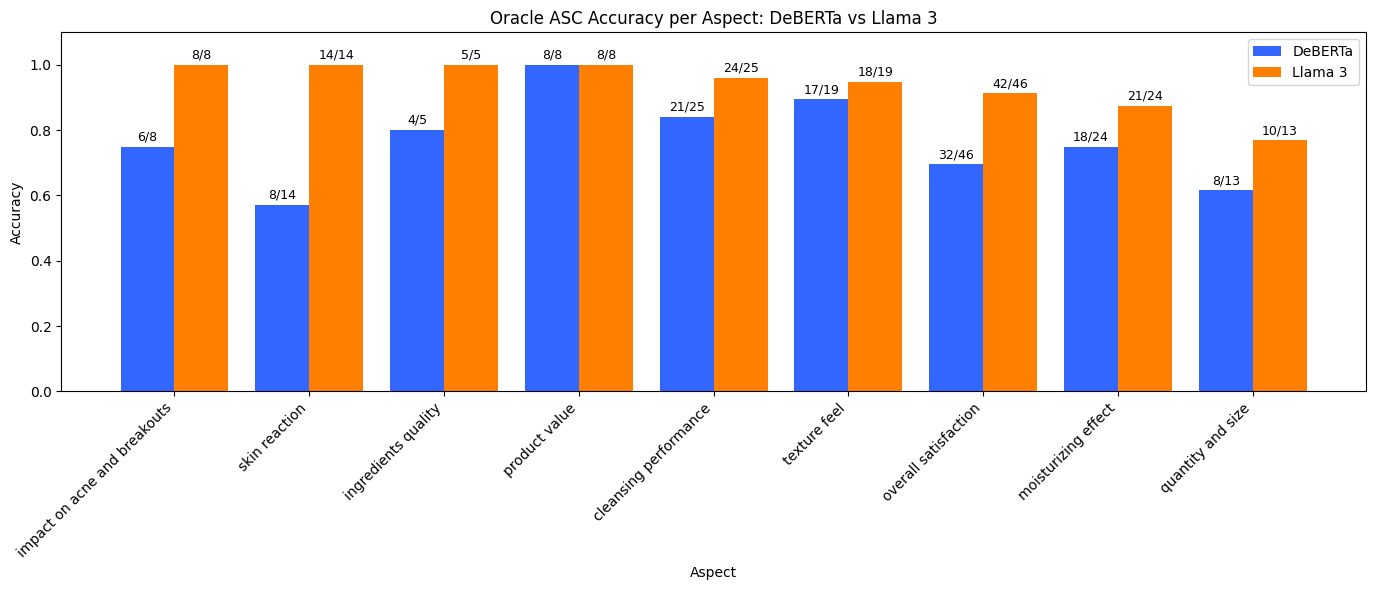

,aspect,deb_acc,correct_deb,total_deb,llm_acc,correct_llm,total_llm
0,impact on acne and breakouts,0.750000,6,8,1.000000,8,8
1,skin reaction,0.571429,8,14,1.000000,14,14
2,ingredients quality,0.800000,4,5,1.000000,5,5
3,product value,1.000000,8,8,1.000000,8,8
4,cleansing performance,0.840000,21,25,0.960000,24,25
5,texture feel,0.894737,17,19,0.947368,18,19
6,overall satisfaction,0.695652,32,46,0.913043,42,46
7,moisturizing effect,0.750000,18,24,0.875000,21,24
8,quantity and size,0.615385,8,13,0.769231,10,13


In [14]:
# %%
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# LLM results
df_llm = pd.DataFrame(llm_predictions)
aspect_perf_llm = df_llm.groupby("aspect").agg(
    total=("aspect", "size"),
    correct=("is_correct", "sum")
).reset_index()
aspect_perf_llm["llm_acc"] = aspect_perf_llm["correct"] / aspect_perf_llm["total"]

# DeBERTa results (from your existing df_oracle)
df_deb = df_oracle.copy()
aspect_perf_deb = df_deb.groupby("aspect").agg(
    total=("aspect", "size"),
    correct=("is_correct", "sum")
).reset_index()
aspect_perf_deb["deb_acc"] = aspect_perf_deb["correct"] / aspect_perf_deb["total"]

# Merge to align aspects (inner join ensures same aspects on both)
aspect_perf = aspect_perf_llm.merge(
    aspect_perf_deb[["aspect", "deb_acc", "total", "correct"]],
    on="aspect",
    suffixes=("_llm", "_deb"),
    how="inner"
)

# Sort by LLM accuracy (or change to deb_acc if you prefer)
aspect_perf = aspect_perf.sort_values("llm_acc", ascending=False).reset_index(drop=True)

# Plot grouped bars
plt.figure(figsize=(14, 6))
x = np.arange(len(aspect_perf))
bar_w = 0.4

bars_deb = plt.bar(
    x - bar_w / 2,
    aspect_perf["deb_acc"],
    width=bar_w,
    color=(0.2, 0.4, 1.0),  # blue
    label="DeBERTa"
)

bars_llm = plt.bar(
    x + bar_w / 2,
    aspect_perf["llm_acc"],
    width=bar_w,
    color=(1.0, 0.5, 0.0),  # orange
    label="Llama 3"
)

plt.xticks(x, aspect_perf["aspect"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Aspect")
plt.title("Oracle ASC Accuracy per Aspect: DeBERTa vs Llama 3")
plt.ylim(0, 1.1)
plt.legend()

# Add labels on bars: correct/total for each model (from each model's own counts)
for bar, total, correct in zip(bars_deb, aspect_perf["total_deb"], aspect_perf["correct_deb"]):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{correct}/{total}", ha="center", va="bottom", fontsize=9)

for bar, total, correct in zip(bars_llm, aspect_perf["total_llm"], aspect_perf["correct_llm"]):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{correct}/{total}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

display(aspect_perf[[
    "aspect",
    "deb_acc", "correct_deb", "total_deb",
    "llm_acc", "correct_llm", "total_llm"
]])


C:\Users\joels\AppData\Local\Temp\ipykernel_28512\1536883831.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_perf_llm = df_llm.groupby("length_bin").agg(


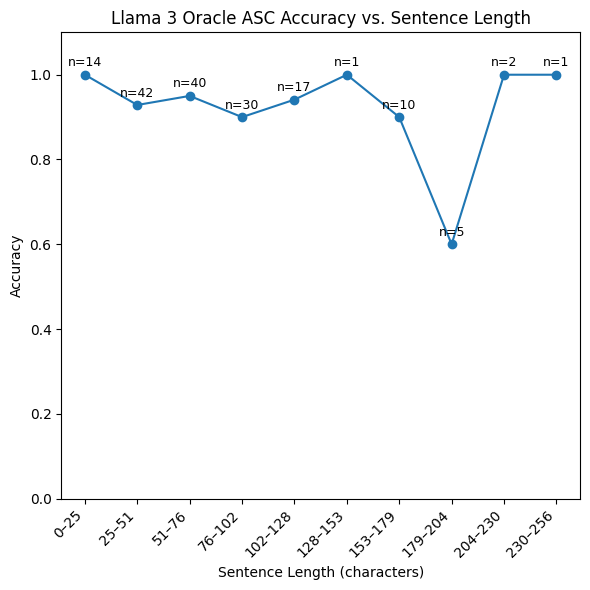

,length_bin,total,correct,accuracy,bin_label
0,"(-0.001, 25.0]",14,14,1.000000,0–25
1,"(25.0, 51.0]",42,39,0.928571,25–51
2,"(51.0, 76.0]",40,38,0.950000,51–76
3,"(76.0, 102.0]",30,27,0.900000,76–102
4,"(102.0, 128.0]",17,16,0.941176,102–128
5,"(128.0, 153.0]",1,1,1.000000,128–153
6,"(153.0, 179.0]",10,9,0.900000,153–179
7,"(179.0, 204.0]",5,3,0.600000,179–204
8,"(204.0, 230.0]",2,2,1.000000,204–230
9,"(230.0, 256.0]",1,1,1.000000,230–256


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Build dataframe from results
df_llm = pd.DataFrame(llm_predictions)

# Add sentence text and length
df_llm["text"] = df_llm["sentence_id"].apply(lambda sid: raw_sentences[sid])
df_llm["text_length"] = df_llm["text"].apply(len)
df_llm["correct"] = df_llm["is_correct"].astype(int)

# Define clean integer bins
max_len = df_llm["text_length"].max()
bin_edges = np.linspace(0, max_len, 11).astype(int)

# Create bins
df_llm["length_bin"] = pd.cut(
    df_llm["text_length"],
    bins=bin_edges,
    include_lowest=True
)

# Compute accuracy per length bin
length_perf_llm = df_llm.groupby("length_bin").agg(
    total=("correct", "size"),
    correct=("correct", "sum")
).reset_index()

length_perf_llm["accuracy"] = length_perf_llm["correct"] / length_perf_llm["total"]

# Build clean labels
length_perf_llm["bin_label"] = length_perf_llm["length_bin"].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(range(len(length_perf_llm)), length_perf_llm["accuracy"], marker="o")

plt.xticks(
    range(len(length_perf_llm)),
    length_perf_llm["bin_label"],
    rotation=45,
    ha="right"
)

plt.xlabel("Sentence Length (characters)")
plt.ylabel("Accuracy")
plt.title("Llama 3 Oracle ASC Accuracy vs. Sentence Length")
plt.ylim(0, 1.1)

# Add sample counts
for i, (acc, total) in enumerate(zip(length_perf_llm["accuracy"], length_perf_llm["total"])):
    plt.text(i, acc + 0.02, f"n={total}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

display(length_perf_llm)


### [10]. DeBERTa vs Llama 3 performance comparison

Compares specialist and generalist models.

- Aligns ground truth labels with LLM and DeBERTa predictions.
- Computes macro F1 for both systems.
- Prints a detailed classification report for Llama 3.
- Performs win/loss analysis to find cases where the LLM outperforms DeBERTa.


In [16]:
print("=" * 60)
print("FINAL RESULTS: DeBERTa vs. Llama 3 ")
print("=" * 60)

def base_sentence_id(review_id: str) -> str:
    return str(review_id).split(":", 1)[0]

# Build LLM dataframe (same values as earlier blocks)
df_llm = pd.DataFrame(llm_predictions).rename(columns={
    "pred_label": "LLM",
    "true_label": "truth"
})
df_llm["sentence_id"] = df_llm["review_id"].apply(base_sentence_id)

# Build DeBERTa dataframe (same values as earlier blocks)
df_deb = df_oracle.rename(columns={
    "pred_label": "DeBERTa",
    "pred_score": "DeBERTa_score"
}).copy()
df_deb["sentence_id"] = df_deb["review_id"].apply(base_sentence_id)

# Join on the unique (review_id, aspect) pair
# Include sentence_id in the merge to avoid suffix issues
df_compare = df_deb.merge(
    df_llm[["review_id", "aspect", "sentence_id", "truth", "LLM"]],
    on=["review_id", "aspect", "sentence_id"],  # Added sentence_id here
    how="inner"
)

# Add sentence text using sentence_id (base id)
df_compare["text"] = df_compare["sentence_id"].apply(lambda sid: raw_sentences[sid])

# Keep only rows where the models disagree
diffs = df_compare[df_compare["DeBERTa"] != df_compare["LLM"]].copy()

print(f"Total disagreements: {len(diffs)} out of {len(df_compare)} examples.")

# Who is correct when they disagree
llm_right = diffs[(diffs["LLM"] == diffs["truth"]) & (diffs["DeBERTa"] != diffs["truth"])]
deb_right = diffs[(diffs["DeBERTa"] == diffs["truth"]) & (diffs["LLM"] != diffs["truth"])]
both_wrong = diffs[(diffs["LLM"] != diffs["truth"]) & (diffs["DeBERTa"] != diffs["truth"])]

print(f"LLM wins (LLM correct, DeBERTa wrong): {len(llm_right)}")
print(f"DeBERTa wins (DeBERTa correct, LLM wrong): {len(deb_right)}")
print(f"Both wrong (different wrong labels): {len(both_wrong)}")

# Macro F1 delta
y_true = df_compare["truth"].tolist()
y_pred_deb = df_compare["DeBERTa"].tolist()
y_pred_llm = df_compare["LLM"].tolist()

deb_macro = f1_score(y_true, y_pred_deb, average="macro")
llm_macro = f1_score(y_true, y_pred_llm, average="macro")

print("\nMacro F1 delta:")
print(f"DeBERTa Macro F1: {deb_macro:.4f}")
print(f"Llama 3 Macro F1: {llm_macro:.4f}")
print(f"Difference:       {(llm_macro - deb_macro):.4f}")

# Example wins (still useful)
print("\nExample LLM wins (LLM right, DeBERTa wrong):")
display(
    llm_right[[
        "review_id", "aspect", "truth", "DeBERTa", "DeBERTa_score", "LLM", "text"
    ]]
    .sort_values("DeBERTa_score", ascending=False)
    .head(5)
)

print("\nExample DeBERTa wins (DeBERTa right, LLM wrong):")
display(
    deb_right[[
        "review_id", "aspect", "truth", "DeBERTa", "DeBERTa_score", "LLM", "text"
    ]]
    .sort_values("DeBERTa_score", ascending=False)
    .head(5)
)

FINAL RESULTS: DeBERTa vs. Llama 3 
Total disagreements: 46 out of 162 examples.
LLM wins (LLM correct, DeBERTa wrong): 36
DeBERTa wins (DeBERTa correct, LLM wrong): 8
Both wrong (different wrong labels): 2

Macro F1 delta:
DeBERTa Macro F1: 0.6096
Llama 3 Macro F1: 0.8368
Difference:       0.2272

Example LLM wins (LLM right, DeBERTa wrong):


,review_id,aspect,truth,DeBERTa,DeBERTa_score,LLM,text
148,C3_34_1,ingredients quality,Negative,Neutral,0.9995,Negative,used to love but after reading ingredients wil...
113,C3_17_1,cleansing performance,Negative,Positive,0.9984,Negative,very gental but not thorough
117,C3_20_1,skin reaction,Positive,Neutral,0.9979,Positive,i like this face soap because it is soft and d...
120,C3_21_1,overall satisfaction,Neutral,Positive,0.9968,Neutral,good cleaner but has not helped me.
150,C1_1_2,overall satisfaction,Negative,Positive,0.9964,Negative,it's essentially their lotion rebottled to mak...



Example DeBERTa wins (DeBERTa right, LLM wrong):


,review_id,aspect,truth,DeBERTa,DeBERTa_score,LLM,text
134,C3_26_1,overall satisfaction,Positive,Positive,0.9996,Negative,"nice product, but terrible dispenser pump."
101,C3_12_1:2,overall satisfaction,Positive,Positive,0.9983,Neutral,it cleans well and leaves the skin feeling fre...
54,C5_13_1:3,quantity and size,Positive,Positive,0.9956,Neutral,perfect everyday face wash and definitely chan...
88,C3_3_1:1,overall satisfaction,Positive,Positive,0.9950,Neutral,"love this cleanser, but more than once the pum..."
103,C3_12_2:2,moisturizing effect,Positive,Positive,0.9427,Neutral,the texture is nice and it doesn’t dry out the...


### [13] Graph 3: Head-to-head net wins by aspect (LLM wins minus DeBERTa wins)
- Identifies which aspects each model is stronger on. Positive bar = Llama advantage. Negative bar = DeBERTa advantage.


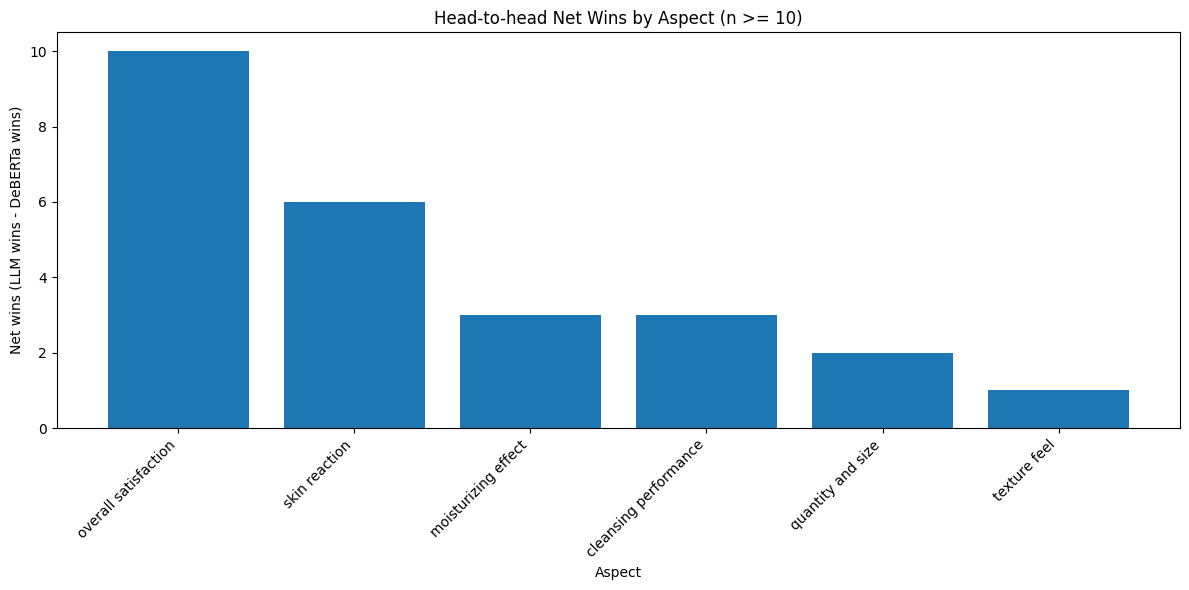

,aspect,n,llm_wins,deb_wins,net_llm_wins
4,overall satisfaction,46,14,4,10
7,skin reaction,14,6,0,6
3,moisturizing effect,24,4,1,3
0,cleansing performance,25,3,0,3
6,quantity and size,13,4,2,2
8,texture feel,19,2,1,1


In [17]:
# %%
import matplotlib.pyplot as plt
import pandas as pd

df_aspect = df_compare.copy()

df_aspect["llm_win"] = (df_aspect["LLM"] == df_aspect["truth"]) & (df_aspect["DeBERTa"] != df_aspect["truth"])
df_aspect["deb_win"] = (df_aspect["DeBERTa"] == df_aspect["truth"]) & (df_aspect["LLM"] != df_aspect["truth"])

aspect_summary = df_aspect.groupby("aspect").agg(
    n=("aspect", "size"),
    llm_wins=("llm_win", "sum"),
    deb_wins=("deb_win", "sum")
).reset_index()

aspect_summary["net_llm_wins"] = aspect_summary["llm_wins"] - aspect_summary["deb_wins"]

# Keep aspects with enough samples to be meaningful (tune threshold if needed)
MIN_N = 10
aspect_summary = aspect_summary[aspect_summary["n"] >= MIN_N].copy()

aspect_summary = aspect_summary.sort_values("net_llm_wins", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(aspect_summary["aspect"], aspect_summary["net_llm_wins"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Aspect")
plt.ylabel("Net wins (LLM wins - DeBERTa wins)")
plt.title(f"Head-to-head Net Wins by Aspect (n >= {MIN_N})")
plt.tight_layout()
plt.show()

display(aspect_summary)



### [12] Graph 2: Error rate vs. DeBERTa confidence (pred_score bins)
- Answers: "When DeBERTa is confident, is it actually right? And does Llama beat it on high-confidence mistakes?"


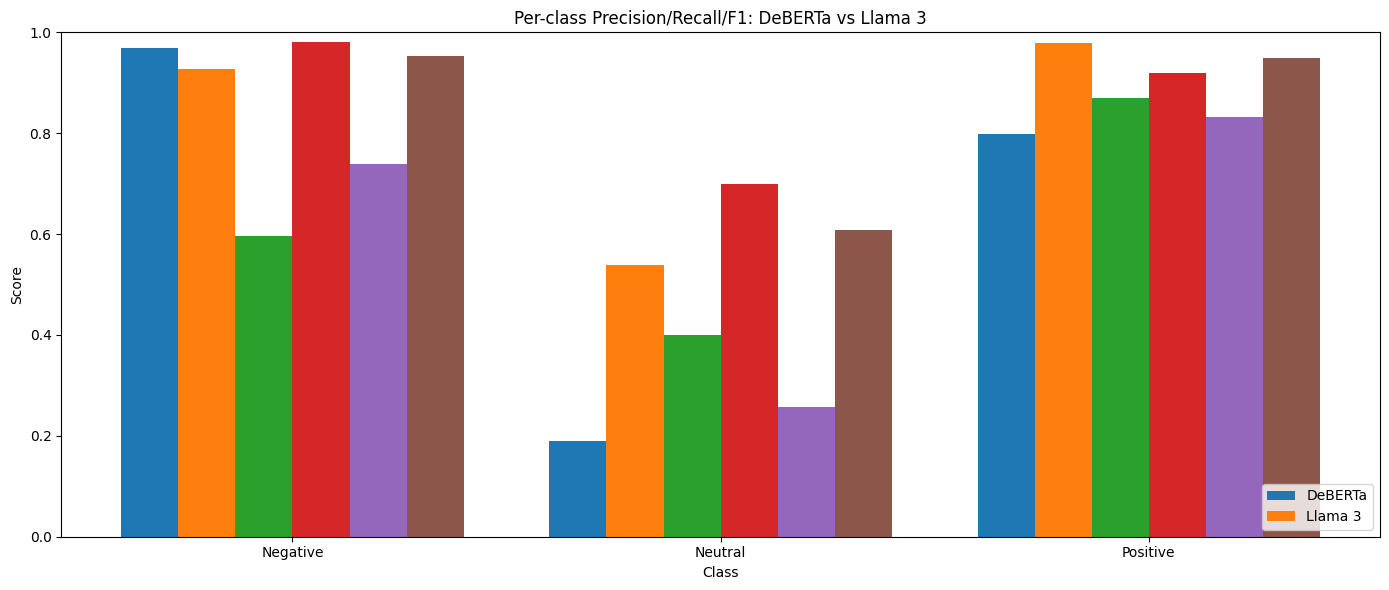

,class,DeBERTa_precision,DeBERTa_recall,DeBERTa_f1,Llama_precision,Llama_recall,Llama_f1
0,Negative,0.968750,0.596154,0.738095,0.927273,0.980769,0.953271
1,Neutral,0.190476,0.400000,0.258065,0.538462,0.700000,0.608696
2,Positive,0.798165,0.870000,0.832536,0.978723,0.920000,0.948454


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

labels = ["Negative", "Neutral", "Positive"]

y_true = df_compare["truth"].tolist()
y_pred_deb = df_compare["DeBERTa"].tolist()
y_pred_llm = df_compare["LLM"].tolist()

p_deb, r_deb, f1_deb, _ = precision_recall_fscore_support(y_true, y_pred_deb, labels=labels, zero_division=0)
p_llm, r_llm, f1_llm, _ = precision_recall_fscore_support(y_true, y_pred_llm, labels=labels, zero_division=0)

metrics_df = pd.DataFrame({
    "class": labels,
    "DeBERTa_precision": p_deb,
    "DeBERTa_recall": r_deb,
    "DeBERTa_f1": f1_deb,
    "Llama_precision": p_llm,
    "Llama_recall": r_llm,
    "Llama_f1": f1_llm,
})

# Plot grouped bars: 3 metrics per class, 2 models per metric
fig, ax = plt.subplots(figsize=(14, 6))

x0 = range(len(labels))
group_w = 0.8
metric_w = group_w / 3
bar_w = metric_w / 2

for mi, metric in enumerate(["precision", "recall", "f1"]):
    xs = [x + (mi - 1) * metric_w for x in x0]
    ax.bar(
        [x - bar_w / 2 for x in xs],
        metrics_df[f"DeBERTa_{metric}"],
        width=bar_w,
        label=f"DeBERTa {metric}" if mi == 0 else None,
    )
    ax.bar(
        [x + bar_w / 2 for x in xs],
        metrics_df[f"Llama_{metric}"],
        width=bar_w,
        label=f"Llama 3 {metric}" if mi == 0 else None,
    )

ax.set_xticks(list(x0))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_xlabel("Class")
ax.set_title("Per-class Precision/Recall/F1: DeBERTa vs Llama 3")

# Custom legend: one entry per model (keep plot readable)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["DeBERTa", "Llama 3"], loc="lower right")

plt.tight_layout()
plt.show()

display(metrics_df)



### [11] Graph 1: Confusion matrices (DeBERTa vs. Llama 3)
- Shows where each model confuses labels, side-by-side.

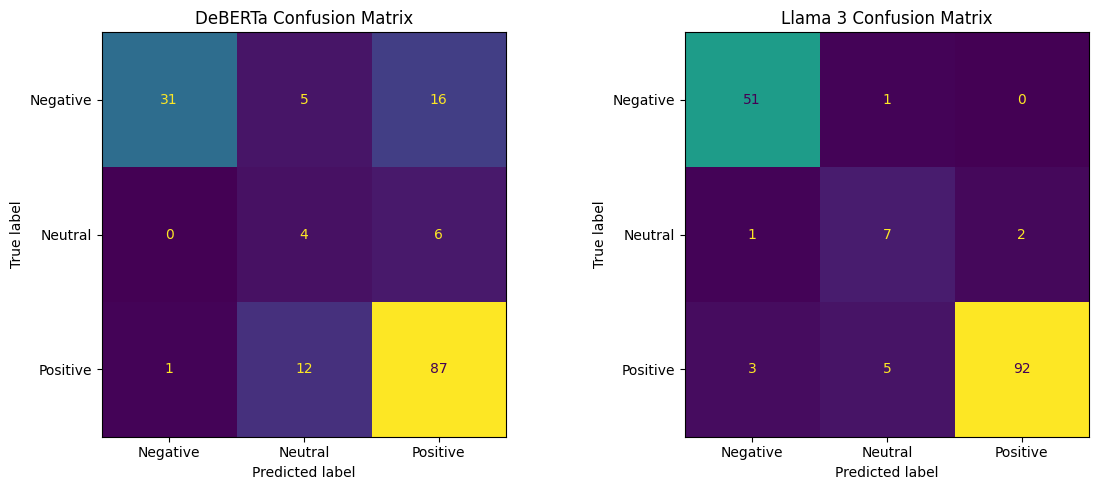

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Negative", "Neutral", "Positive"]

y_true = df_compare["truth"].tolist()
y_pred_deb = df_compare["DeBERTa"].tolist()
y_pred_llm = df_compare["LLM"].tolist()

cm_deb = confusion_matrix(y_true, y_pred_deb, labels=labels)
cm_llm = confusion_matrix(y_true, y_pred_llm, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_deb, display_labels=labels).plot(
    ax=axes[0], colorbar=False, values_format="d"
)
axes[0].set_title("DeBERTa Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix=cm_llm, display_labels=labels).plot(
    ax=axes[1], colorbar=False, values_format="d"
)
axes[1].set_title("Llama 3 Confusion Matrix")

plt.tight_layout()
plt.show()


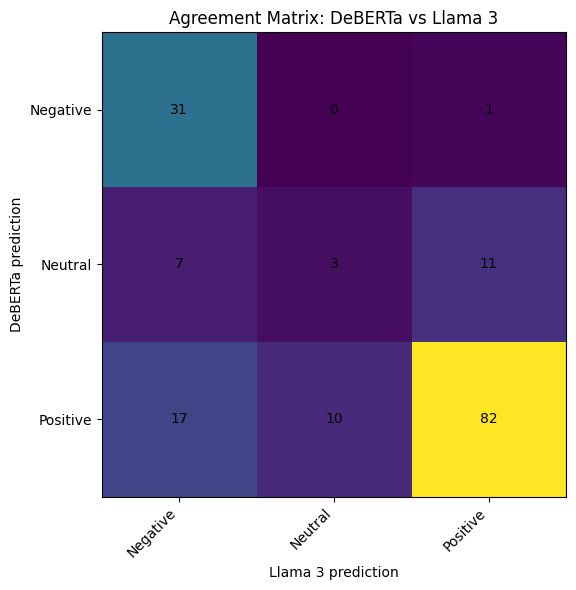

col_0,Negative,Neutral,Positive
row_0,,,
Negative,31,0,1
Neutral,7,3,11
Positive,17,10,82


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

labels = ["Negative", "Neutral", "Positive"]

agreement = pd.crosstab(
    pd.Categorical(df_compare["DeBERTa"], categories=labels, ordered=True),
    pd.Categorical(df_compare["LLM"], categories=labels, ordered=True),
    dropna=False
)

plt.figure(figsize=(7, 6))
plt.imshow(agreement.values)

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.xlabel("Llama 3 prediction")
plt.ylabel("DeBERTa prediction")
plt.title("Agreement Matrix: DeBERTa vs Llama 3")

# Cell annotations
for i in range(agreement.shape[0]):
    for j in range(agreement.shape[1]):
        plt.text(j, i, str(int(agreement.values[i, j])), ha="center", va="center")

plt.tight_layout()
plt.show()

display(agreement)



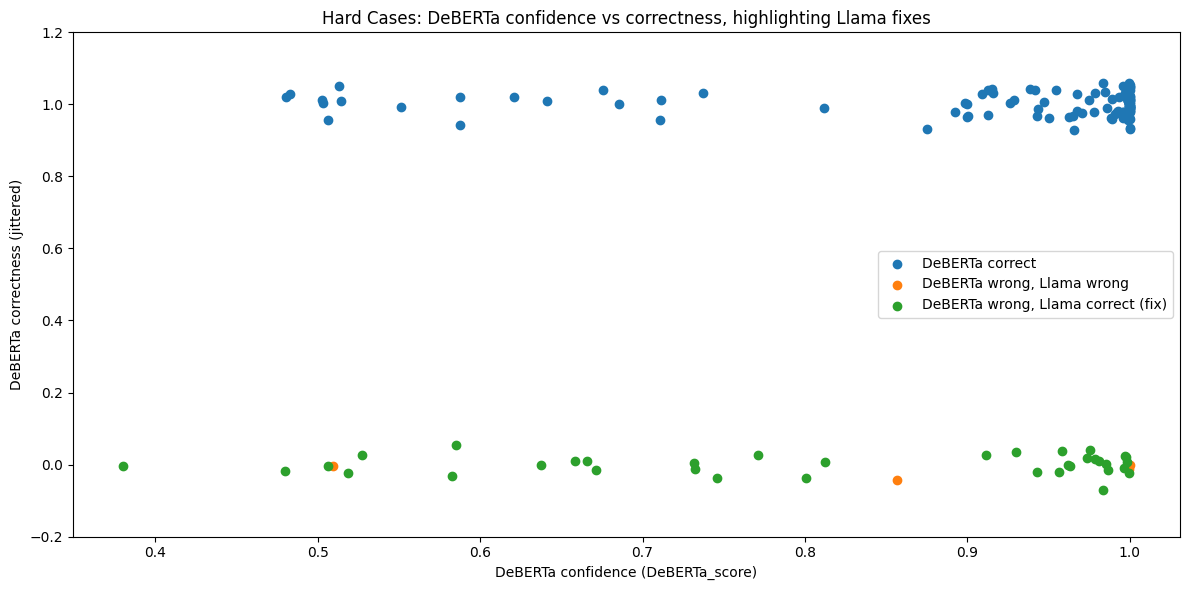

,review_id,aspect,truth,DeBERTa,DeBERTa_score,LLM,text
148,C3_34_1,ingredients quality,Negative,Neutral,0.9995,Negative,used to love but after reading ingredients wil...
113,C3_17_1,cleansing performance,Negative,Positive,0.9984,Negative,very gental but not thorough
117,C3_20_1,skin reaction,Positive,Neutral,0.9979,Positive,i like this face soap because it is soft and d...
120,C3_21_1,overall satisfaction,Neutral,Positive,0.9968,Neutral,good cleaner but has not helped me.
150,C1_1_2,overall satisfaction,Negative,Positive,0.9964,Negative,it's essentially their lotion rebottled to mak...
153,C1_1_4:2,overall satisfaction,Negative,Positive,0.9867,Negative,i have a beard and even trying to lather it on...
25,C5_6_2:1,quantity and size,Positive,Neutral,0.9853,Positive,it requires only a tiny amount to create a lat...
159,C1_4_2,texture feel,Negative,Positive,0.9837,Negative,it is a thick gel with no lather.
50,C5_12_3:3,skin reaction,Positive,Neutral,0.9812,Positive,"doesn’t dry me out, it lathers up so nice, and..."
160,C1_4_3,texture feel,Negative,Positive,0.9788,Negative,would not recommend if you like foaming cleaner.


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_hard = df_compare.copy()
df_hard["deb_correct"] = (df_hard["DeBERTa"] == df_hard["truth"]).astype(int)
df_hard["llm_correct"] = (df_hard["LLM"] == df_hard["truth"]).astype(int)

# Add tiny vertical jitter so overlapping points are visible
rng = np.random.default_rng(0)
df_hard["y_jitter"] = df_hard["deb_correct"] + rng.normal(0, 0.03, size=len(df_hard))

# Split by whether Llama is correct
fixed = df_hard[df_hard["deb_correct"].eq(0) & df_hard["llm_correct"].eq(1)]
not_fixed = df_hard[df_hard["deb_correct"].eq(0) & df_hard["llm_correct"].eq(0)]
deb_correct = df_hard[df_hard["deb_correct"].eq(1)]

plt.figure(figsize=(12, 6))
plt.scatter(deb_correct["DeBERTa_score"], deb_correct["y_jitter"], label="DeBERTa correct")
plt.scatter(not_fixed["DeBERTa_score"], not_fixed["y_jitter"], label="DeBERTa wrong, Llama wrong")
plt.scatter(fixed["DeBERTa_score"], fixed["y_jitter"], label="DeBERTa wrong, Llama correct (fix)")

plt.xlabel("DeBERTa confidence (DeBERTa_score)")
plt.ylabel("DeBERTa correctness (jittered)")
plt.title("Hard Cases: DeBERTa confidence vs correctness, highlighting Llama fixes")
plt.ylim(-0.2, 1.2)

plt.tight_layout()
plt.legend()
plt.show()

display(
    fixed.sort_values("DeBERTa_score", ascending=False)[
        ["review_id", "aspect", "truth", "DeBERTa", "DeBERTa_score", "LLM", "text"]
    ].head(10)
)


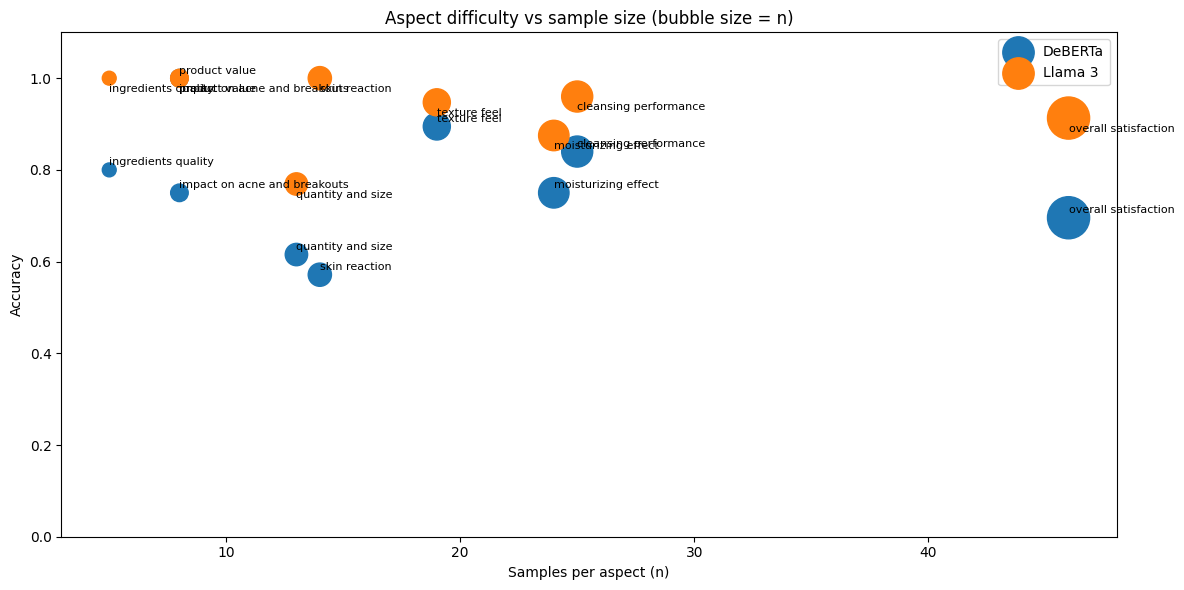

,aspect,n,DeBERTa_acc,Llama_acc
4,overall satisfaction,46,0.695652,0.913043
0,cleansing performance,25,0.840000,0.960000
3,moisturizing effect,24,0.750000,0.875000
8,texture feel,19,0.894737,0.947368
7,skin reaction,14,0.571429,1.000000
6,quantity and size,13,0.615385,0.769231
1,impact on acne and breakouts,8,0.750000,1.000000
5,product value,8,1.000000,1.000000
2,ingredients quality,5,0.800000,1.000000


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

df_aspect = df_compare.copy()
df_aspect["deb_correct"] = (df_aspect["DeBERTa"] == df_aspect["truth"]).astype(int)
df_aspect["llm_correct"] = (df_aspect["LLM"] == df_aspect["truth"]).astype(int)

aspect_stats = df_aspect.groupby("aspect").agg(
    n=("aspect", "size"),
    DeBERTa_acc=("deb_correct", "mean"),
    Llama_acc=("llm_correct", "mean")
).reset_index()

plt.figure(figsize=(12, 6))

# Bubble sizes proportional to n (same scaling for both)
sizes = aspect_stats["n"] * 20

plt.scatter(aspect_stats["n"], aspect_stats["DeBERTa_acc"], s=sizes, label="DeBERTa")
plt.scatter(aspect_stats["n"], aspect_stats["Llama_acc"], s=sizes, label="Llama 3")

# Label points with aspect name
for _, row in aspect_stats.iterrows():
    plt.text(row["n"], row["DeBERTa_acc"] + 0.01, row["aspect"], fontsize=8, ha="left")
    plt.text(row["n"], row["Llama_acc"] - 0.03, row["aspect"], fontsize=8, ha="left")

plt.xlabel("Samples per aspect (n)")
plt.ylabel("Accuracy")
plt.title("Aspect difficulty vs sample size (bubble size = n)")
plt.ylim(0, 1.1)

plt.tight_layout()
plt.legend()
plt.show()

display(aspect_stats.sort_values("n", ascending=False))


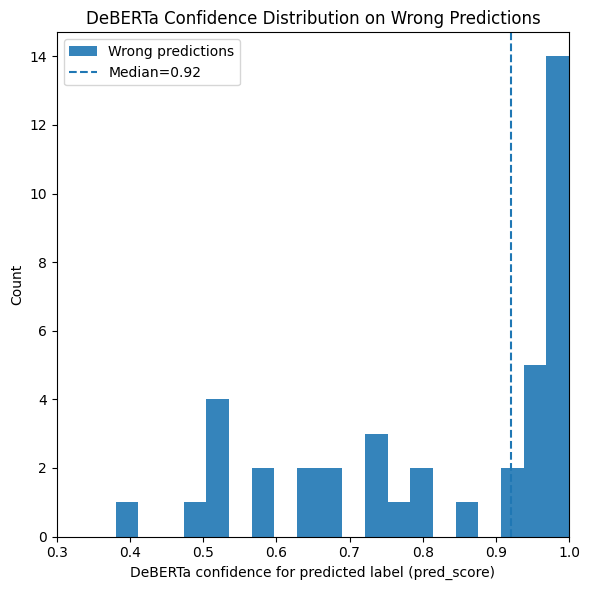

,review_id,aspect,true_label,pred_label,pred_score,text_used
52,C5_13_1:1,moisturizing effect,Negative,Positive,0.9999,perfect everyday face wash and definitely chan...
148,C3_34_1,ingredients quality,Negative,Neutral,0.9995,used to love but after reading ingredients wil...
28,C5_7_2,moisturizing effect,Neutral,Positive,0.9994,my skin is a mix of dry and oily and this seem...
113,C3_17_1,cleansing performance,Negative,Positive,0.9984,very gental but not thorough
117,C3_20_1,skin reaction,Positive,Neutral,0.9979,i like this face soap because it is soft and d...
120,C3_21_1,overall satisfaction,Neutral,Positive,0.9968,good cleaner but has not helped me.
150,C1_1_2,overall satisfaction,Negative,Positive,0.9964,it's essentially their lotion rebottled to mak...
153,C1_1_4:2,overall satisfaction,Negative,Positive,0.9867,i have a beard and even trying to lather it on...
25,C5_6_2:1,quantity and size,Positive,Neutral,0.9853,it requires only a tiny amount to create a lat...
159,C1_4_2,texture feel,Negative,Positive,0.9837,it is a thick gel with no lather.


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_deb = df_oracle.copy()

wrong = df_deb[df_deb["is_correct"] == False].copy()

# Plot distribution of DeBERTa confidence when wrong
plt.figure(figsize=(6, 6))

# Histogram of confidence on wrong predictions
plt.hist(wrong["pred_score"], bins=20, alpha=0.9, label="Wrong predictions")

# Reference line: median wrong-confidence
median_wrong = wrong["pred_score"].median() if len(wrong) > 0 else 0
plt.axvline(median_wrong, linestyle="--", label=f"Median={median_wrong:.2f}")

plt.xlabel("DeBERTa confidence for predicted label (pred_score)")
plt.ylabel("Count")
plt.title("DeBERTa Confidence Distribution on Wrong Predictions")
plt.xlim(0.3, 1)
plt.legend()
plt.tight_layout()
plt.show()

display(
    wrong.sort_values("pred_score", ascending=False)[
        ["review_id", "aspect", "true_label", "pred_label", "pred_score", "text_used"]
    ].head(15)
)


C:\Users\joels\AppData\Local\Temp\ipykernel_28512\846708950.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deb_perf = df_deb.groupby("length_bin").agg(
C:\Users\joels\AppData\Local\Temp\ipykernel_28512\846708950.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  llm_perf = df_llm.groupby("length_bin").agg(


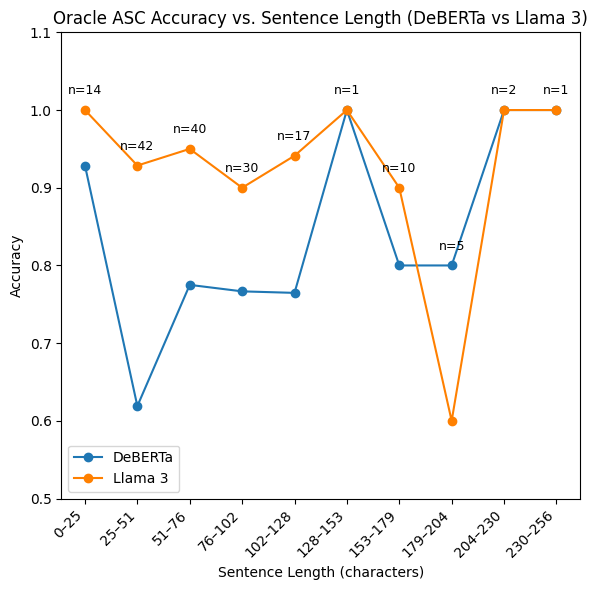

,bin,DeBERTa_accuracy,Llama_accuracy,n
0,0–25,0.928571,1.000000,14
1,25–51,0.619048,0.928571,42
2,51–76,0.775000,0.950000,40
3,76–102,0.766667,0.900000,30
4,102–128,0.764706,0.941176,17
5,128–153,1.000000,1.000000,1
6,153–179,0.800000,0.900000,10
7,179–204,0.800000,0.600000,5
8,204–230,1.000000,1.000000,2
9,230–256,1.000000,1.000000,1


In [24]:
df_deb = pd.DataFrame(results_list)
df_deb["text_length"] = df_deb["text_used"].apply(len)
df_deb["correct"] = df_deb["is_correct"].astype(int)

df_llm = pd.DataFrame(llm_predictions)
df_llm["text"] = df_llm["sentence_id"].apply(lambda sid: raw_sentences[sid])
df_llm["text_length"] = df_llm["text"].apply(len)
df_llm["correct"] = df_llm["is_correct"].astype(int)

max_len = max(df_deb["text_length"].max(), df_llm["text_length"].max())
bin_edges = np.linspace(0, max_len, 11).astype(int)

df_deb["length_bin"] = pd.cut(df_deb["text_length"], bins=bin_edges, include_lowest=True)
df_llm["length_bin"] = pd.cut(df_llm["text_length"], bins=bin_edges, include_lowest=True)

deb_perf = df_deb.groupby("length_bin").agg(
    total=("correct", "size"),
    correct=("correct", "sum")
).reset_index()
deb_perf["accuracy"] = deb_perf["correct"] / deb_perf["total"]

llm_perf = df_llm.groupby("length_bin").agg(
    total=("correct", "size"),
    correct=("correct", "sum")
).reset_index()
llm_perf["accuracy"] = llm_perf["correct"] / llm_perf["total"]

deb_perf["bin_label"] = deb_perf["length_bin"].apply(lambda x: f"{int(x.left)}–{int(x.right)}")

plt.figure(figsize=(6, 6))
x = range(len(deb_perf))

# DeBERTa (blue)
plt.plot(x, deb_perf["accuracy"], marker="o", label="DeBERTa")

# LLM (orange)
plt.plot(x, llm_perf["accuracy"], marker="o", label="Llama 3", color=(1.0, 0.5, 0.0))

plt.xticks(x, deb_perf["bin_label"], rotation=45, ha="right")
plt.xlabel("Sentence Length (characters)")
plt.ylabel("Accuracy")
plt.title("Oracle ASC Accuracy vs. Sentence Length (DeBERTa vs Llama 3)")
plt.ylim(0.5, 1.1)
plt.legend()

for i, total in enumerate(deb_perf["total"]):
    plt.text(i, max(deb_perf["accuracy"][i], llm_perf["accuracy"][i]) + 0.02, f"n={total}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "bin": deb_perf["bin_label"],
    "DeBERTa_accuracy": deb_perf["accuracy"],
    "Llama_accuracy": llm_perf["accuracy"],
    "n": deb_perf["total"]
}))


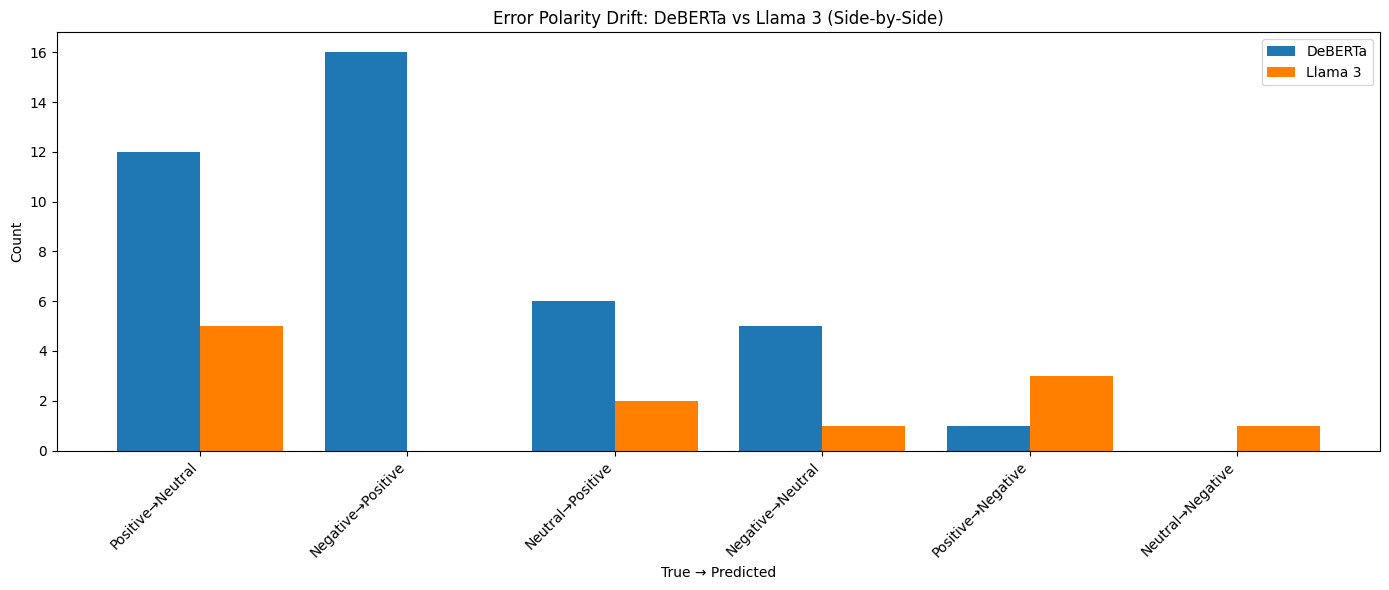

,flip,count_deb,count_llm
5,Positive→Neutral,12,5
1,Negative→Positive,16,0
3,Neutral→Positive,6,2
0,Negative→Neutral,5,1
4,Positive→Negative,1,3
2,Neutral→Negative,0,1


In [25]:

labels = ["Negative", "Neutral", "Positive"]

y_true = df_compare["truth"].tolist()
y_pred_deb = df_compare["DeBERTa"].tolist()
y_pred_llm = df_compare["LLM"].tolist()

cm_deb = confusion_matrix(y_true, y_pred_deb, labels=labels)
cm_llm = confusion_matrix(y_true, y_pred_llm, labels=labels)

def drift_counts(cm, labels):
    rows = []
    for i, t in enumerate(labels):
        for j, p in enumerate(labels):
            if i == j:
                continue
            rows.append({"flip": f"{t}→{p}", "count": int(cm[i, j])})
    return pd.DataFrame(rows)

drift_deb = drift_counts(cm_deb, labels)
drift_llm = drift_counts(cm_llm, labels)

# Align both models on the same flip order
drift = drift_deb.merge(drift_llm, on="flip", suffixes=("_deb", "_llm"))

# Sort by total errors for nicer ordering
drift["total"] = drift["count_deb"] + drift["count_llm"]
drift = drift.sort_values("total", ascending=False)

# Plot side-by-side bars
x = np.arange(len(drift))
bar_w = 0.4

plt.figure(figsize=(14, 6))

plt.bar(x - bar_w / 2, drift["count_deb"], width=bar_w, label="DeBERTa")
plt.bar(x + bar_w / 2, drift["count_llm"], width=bar_w, label="Llama 3", color=(1.0, 0.5, 0.0))

plt.xticks(x, drift["flip"], rotation=45, ha="right")
plt.xlabel("True → Predicted")
plt.ylabel("Count")
plt.title("Error Polarity Drift: DeBERTa vs Llama 3 (Side-by-Side)")
plt.legend()

plt.tight_layout()
plt.show()

display(drift[["flip", "count_deb", "count_llm"]])
